In [9]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd

#para especificar cuantos numeros se visualizan en los ejes de las gráficas
from matplotlib.ticker import MaxNLocator

#para el estudio de redes
import networkx as nx

#para guardar en ficheros
import csv

#para limpiar RAM
import gc

#para mapas de calor
from cmcrameri import cm

#data = xr.open_dataset('air.mon.1981-2010.ltm.nc') #para leer la media a largo plazo, 0.995 sigma (?)
data = xr.open_dataset('air.2m.mon.mean.nc') #para leer la media de cada mes a 2m de altura
#data = xr.open_dataset('air.2m.4Xday.ltm.1991-2020.nc') #para leer x4 day a 2m altura de media a largo plazo

#print(data)

temperatura = data['air']
#print(temperatura)
print(temperatura.time.size)
#print(temperatura.time.values) #muestra los valores de la lista level que se encuentra dentro del xarray temperatura




937


## Representación gráfica

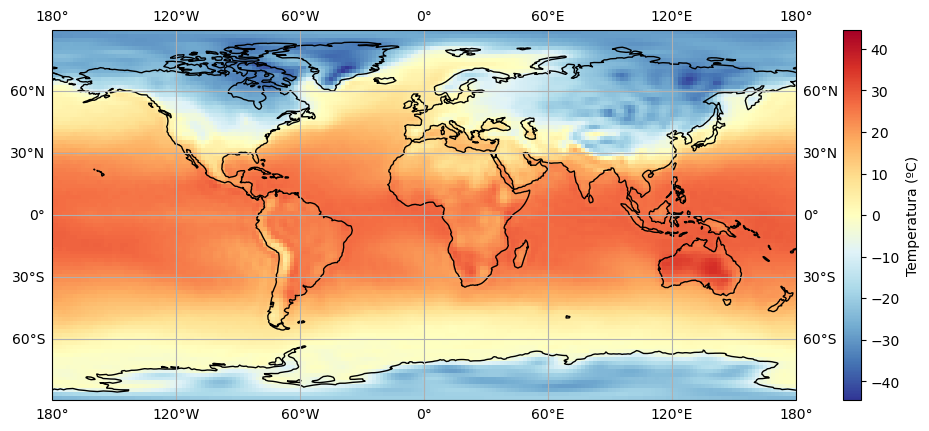

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

year_selected = 2018
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

temperatura_celsius = temperatura - 273.15

im = temperatura_celsius.sel(time=date_selected).plot( #como estamos especificando la fecha, hay que usar .sel() en vez de .isel()
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    add_colorbar=True,
    cbar_kwargs={'shrink': 0.8, 'label': 'Temperatura (ºC)'}
)

ax.coastlines(resolution='110m', color='black', linewidth=1.0)
#ax.add_feature(cfeature.BORDERS, linestyle=':') #muestra las fronteras de los paises
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) #muestra la cuadrícula de coordenadas
ax.set_title("")


#plt.title(f'Temperatura del aire ({date_selected})')
plt.show()

#temperatura.isel(time=0).plot() #.isel() me permite seleccionar los elementos de temperatura por posición

#plt.show()

#np.shape(temperatura['time'])



## Global Mean Surface Air Temperature


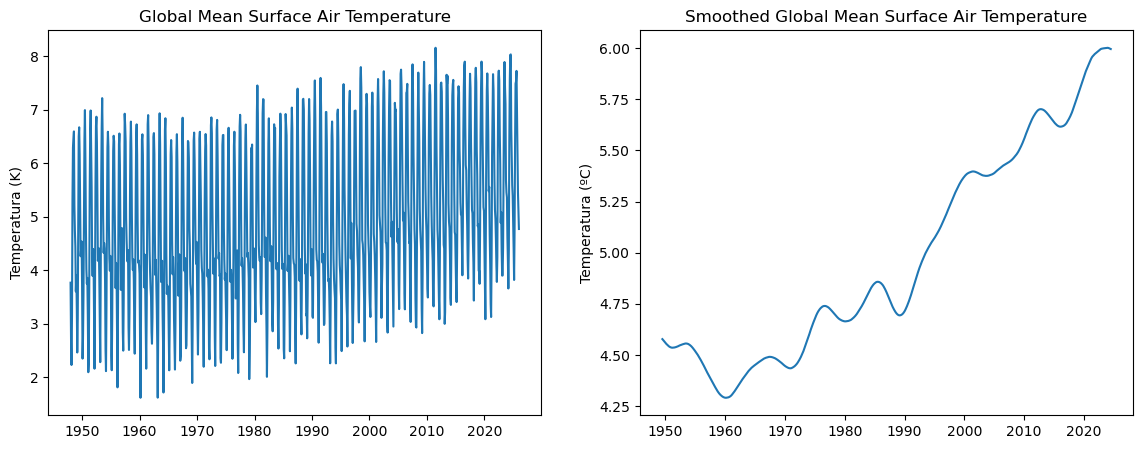

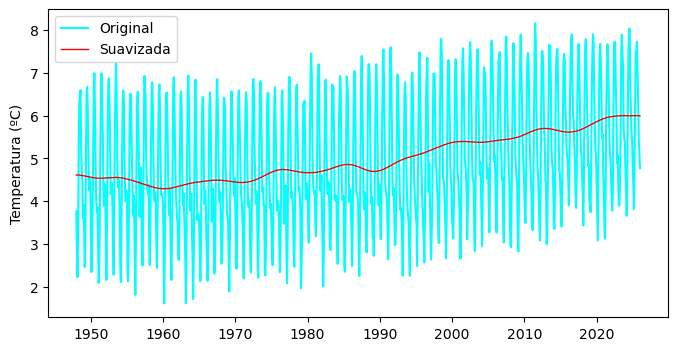

In [11]:
#quiero representar la media de temperatura de todo el globo terráqueo de cada mes a lo largo de los años 

year_selected = 2001
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

global_mean_temp = temperatura_celsius.mean(dim=['lat', 'lon'])
#print(global_mean_temp)

fig, ax = plt.subplots(1, 2, figsize=(14, 5)) #un marco fig que contiene dos gráficas ax

ax[0].set_title('Global Mean Surface Air Temperature')
ax[0].set_ylabel('Temperatura (K)')
temp_plot = ax[0].plot(global_mean_temp.time, global_mean_temp)

#slow window moving average


n_smooth = 3 #numero de veces que se suaviza la gráfica
step_size = 1 #intervalo de tiempo que se mueve la ventana, ha de ser siempre menor que la longitud de la ventana
window = 37 #longitud de la ventana

aux = global_mean_temp

def smooth_data(aux, n_smooth, step_size, window):

    """
        esta funcion suaviza una serie lineal de datos usando el metodo de 'sliding window moving average'

        n_smooth: numero de veces que hacemos el recorrido de suavizado
        step_size: distancia que se mueve la ventana en el eje x
        window: anchura de la ventana de promediados


    """

    for i in range(n_smooth):

        smoothed = np.zeros(aux.size)
        win_val = np.zeros(window)
        win_center = 0
        inicio = 0
        final = 0
        count = 0

        while (win_center < aux.size):
            if win_center < int(window/2):
                smoothed[win_center] = np.mean(aux[0:(win_center + int(window/2))]).item()

            if win_center > aux.size - 1 - int(window/2):
                smoothed[win_center] = np.mean(aux[(win_center - int(window/2)):(aux.size - 1)]).item()
        
            else:
                inicio = count
                final = count + window + 1
                #print(final)
                #print(np.mean(aux[inicio:final]).item())
                smoothed[win_center] = np.mean(aux[inicio:final]).item()
                #print(win_center)
            count = count + step_size
            win_center = win_center + step_size
        #print(smoothed)
        aux = smoothed

    return aux

smoothed = smooth_data(aux, n_smooth, step_size, window)

ax[1].set_title('Smoothed Global Mean Surface Air Temperature')
ax[1].set_ylabel('Temperatura (ºC)')

#temp_plot = ax[1].plot(global_mean_temp.time, smoothed)
temp_plot = ax[1].plot(global_mean_temp.time[int(window/2):937-int(window/2)], smoothed[int(window/2):937-int(window/2)]) #en la representación grafica elimino los puntos que no han sido promediados por la funcion

plt.show()

fig = plt.figure(figsize=(8, 4))

plt.plot(global_mean_temp.time, global_mean_temp, label='Original', color='cyan')
plt.plot(global_mean_temp.time, smoothed, label='Suavizada', color='red', linewidth = '1')
#plt.title('Global Mean Surface Air Temperature')
#plt.xlabel('Tiempo')
plt.ylabel('Temperatura (ºC)')

plt.legend()

plt.show()

## Estandarización de datos y cálculo de anomalías

('time', 'lat', 'lon')


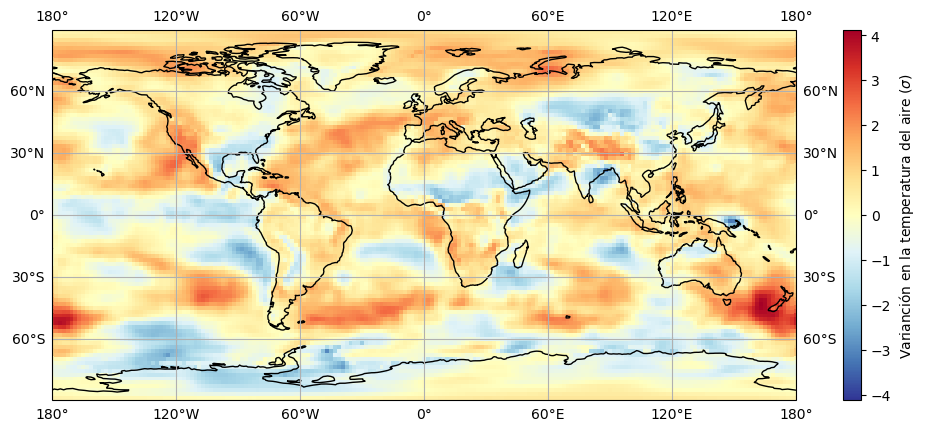

937


In [12]:
# Standardize Data
climatology = temperatura.groupby('time.month').mean('time') #.groupby() segmenta los datos agrupandolos por meses, de tal forma que la media se aplica de forma independiente a cada uno de dichos segmentos
std_dev = temperatura.groupby('time.month').std('time')
anomalies = (temperatura.groupby('time.month') - climatology) / std_dev #.groupby() hace la misma segmentación de climatology y std_dev, por lo que la operación es muy sencilla

# .groupby() genera una nueva dimension (month) en el DataArray, el siguiente condicional (generado por Gemini) elimina dicha dimension, quedandonos de nuevo con ('time', 'lat', 'lon')

if 'month' in anomalies.dims:
    # Seleccionamos el primer elemento de 'month' y lo eliminamos
    anomalies = anomalies.isel(month=0).drop_vars('month')
elif 'month' in anomalies.coords:
    # Si solo es una coordenada, la borramos así
    anomalies = anomalies.drop_vars('month')

year_selected = 2018
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

print(anomalies.dims)
im = anomalies.sel(time=date_selected).plot( 
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': r'Varianción en la temperatura del aire ($\sigma$)', 'shrink': 0.8}
)

ax.coastlines(resolution='110m', color='black', linewidth=1.0)
#ax.add_feature(cfeature.BORDERS, linestyle=':') #muestra las fronteras de los paises
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) #muestra la cuadrícula de coordenadas
ax.set_title("")
#plt.title(f'Anomalías estandarizadas en la temperatura ({date_selected})')
plt.show()

print(anomalies.time.size)

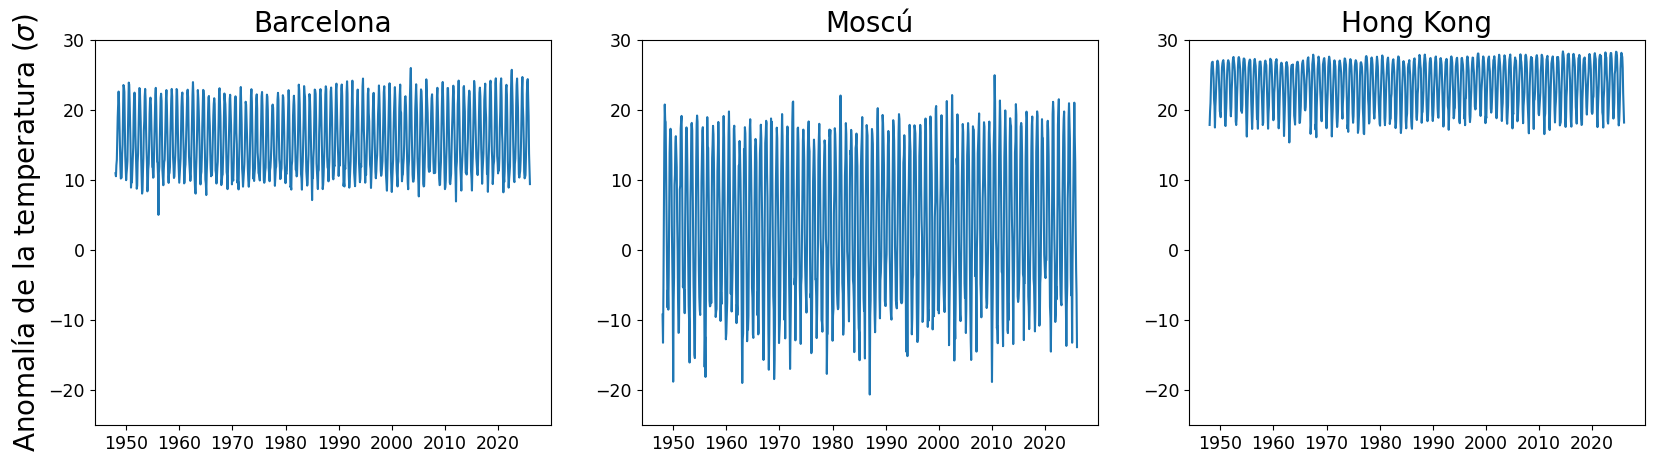

In [13]:
barcelona = temperatura_celsius.sel(lat = 41.38, lon = 2.17, method='nearest')
moscu = temperatura_celsius.sel(lat = 55.75, lon = 37.60, method = 'nearest')
hongkong = temperatura_celsius.sel(lat = 22.25, lon = 114.08, method = 'nearest')

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title('Barcelona', fontsize = 20)
ax[0].set_ylabel(r'Anomalía de la temperatura ($\sigma$)', fontsize = 20)
ax[0].tick_params(axis='both', labelsize=12.5)
barcelona_plot = ax[0].plot(barcelona.time, barcelona)

ax[1].set_title('Moscú', fontsize = 20)
ax[1].tick_params(axis='both', labelsize=12.5)
moscu_plot = ax[1].plot(moscu.time, moscu)

ax[2].set_title('Hong Kong', fontsize = 20)
ax[2].tick_params(axis='both', labelsize=12.5)
hongkong_plot = ax[2].plot(hongkong.time, hongkong)


for v_ax in ax:
    v_ax.set_ylim(-25, 30)

plt.show()

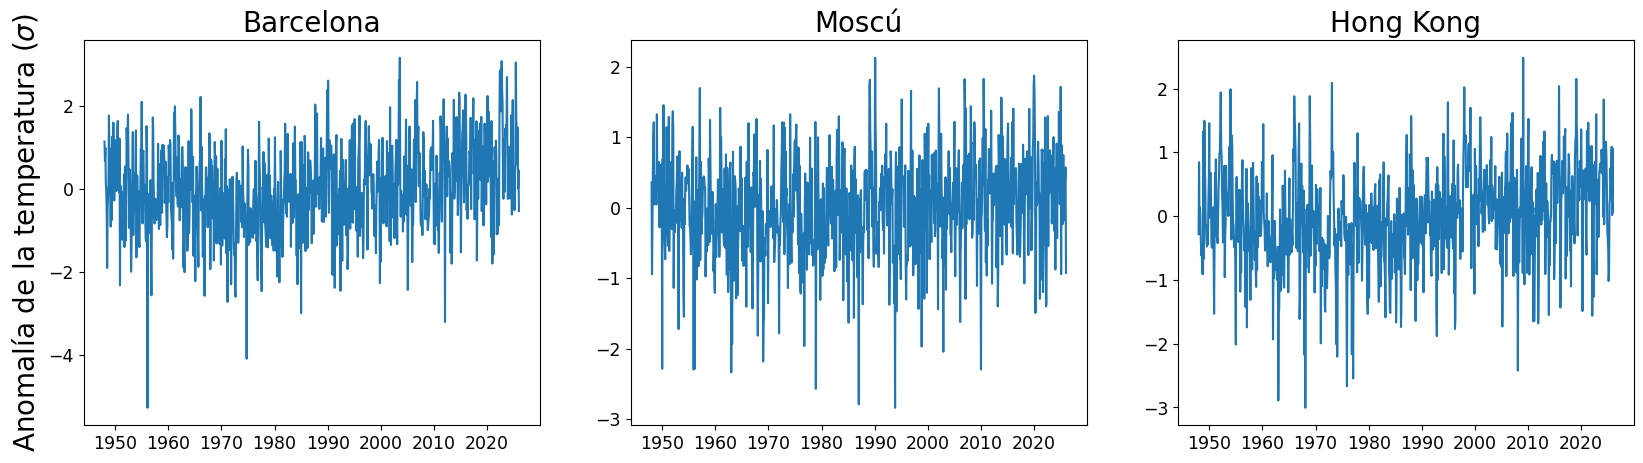

In [14]:
barcelona = anomalies.sel(lat = 41.38, lon = 2.17, method='nearest')
moscu = anomalies.sel(lat = 55.75, lon = 37.60, method = 'nearest')
hongkong = anomalies.sel(lat = 22.25, lon = 114.08, method = 'nearest')

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title('Barcelona', fontsize = 20)
ax[0].set_ylabel(r'Anomalía de la temperatura ($\sigma$)', fontsize = 20)
ax[0].tick_params(axis='both', labelsize=12.5)
barcelona_plot = ax[0].plot(barcelona.time, barcelona)

ax[1].set_title('Moscú', fontsize = 20)
ax[1].tick_params(axis='both', labelsize=12.5)
moscu_plot = ax[1].plot(moscu.time, moscu)

ax[2].set_title('Hong Kong', fontsize = 20)
ax[2].tick_params(axis='both', labelsize=12.5)
hongkong_plot = ax[2].plot(hongkong.time, hongkong)

plt.show()

# Implementación de redes



## Matriz de correlaciones

In [15]:
def fast_corr_matrix(grid):
    """
    Calcula la matriz de correlacion entre todos los puntos de un grid espacial.
    El grid es  esprado en formator xarray con dimensiones (time, lat, lon).
    Esta funcion es rapida porque el calculo de correlación se hace de forma vectorizada usando numpy.
    """
    
    # Lo primro es el grid 3d a un 2d (time, lat, lon) -> (time, node)
    grid_stacked = grid.stack(node=('lat', 'lon'))
    
    # Ahora quitamos la carga de lidiar con los metadatos durante el calculo.
    data_matrix = grid_stacked.values 
    
    # Ahora solo queda el calculo de la matriz de correlacion, que se hace de forma vectorizada con numpy
    # rowvar=False decimos que la variables están en las columnas.
    print("Calculando matriz de correlacion")
    correlations = np.corrcoef(data_matrix, rowvar=False)
    
    return correlations, grid_stacked.node.values, grid_stacked.node.coords, grid_stacked.node


In [16]:
corr, nodos_val, coordinates, nodos = fast_corr_matrix(anomalies)
print(corr.shape)

Calculando matriz de correlacion
(18048, 18048)


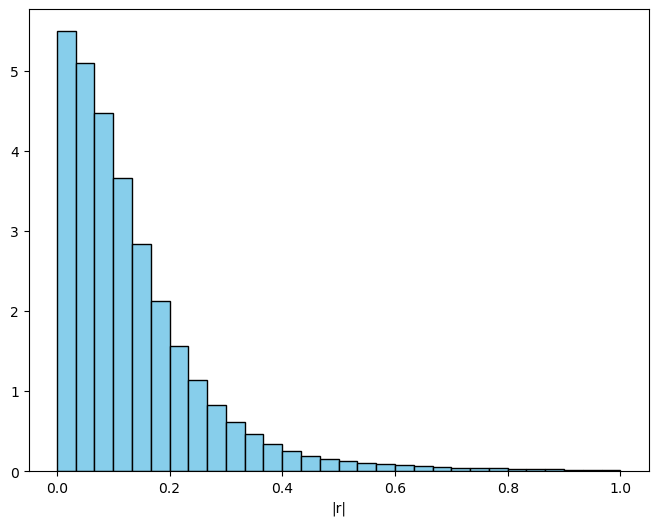

In [17]:
#histograma de las correlaciones

# Crear el histograma
plt.figure(figsize=(8, 6))
plt.hist(np.abs(corr.flatten()), bins=30, color='skyblue', edgecolor='black', density=True)

# Añadir etiquetas y título
#plt.title('Histograma de correlaciones')
plt.xlabel('|r|')

# Mostrar el gráfico
plt.show()

In [18]:
import os

file_name = os.path.join("corr_matrices", "first_try.txt")
#print(corr)
np.savetxt(file_name, corr, fmt='%.10f', delimiter=',') #guardo la matriz de correlaciones en un archivo de texto


In [10]:
import os

file_name = os.path.join("corr_matrices", "first_try.txt")

correlaciones = np.loadtxt(file_name, delimiter=',')
print(correlaciones)

[[1.         0.99995163 0.99981851 ... 0.154845   0.15516647 0.15533441]
 [0.99995163 1.         0.99995348 ... 0.15470481 0.15501834 0.1551809 ]
 [0.99981851 0.99995348 1.         ... 0.15448271 0.15478861 0.15494461]
 ...
 [0.154845   0.15470481 0.15448271 ... 1.         0.99991484 0.99965675]
 [0.15516647 0.15501834 0.15478861 ... 0.99991484 1.         0.9999073 ]
 [0.15533441 0.1551809  0.15494461 ... 0.99965675 0.9999073  1.        ]]


## Surrogate data testing

In [7]:
def gen_random_grid(grid):
    """
        esta función coge nuestro array de datos, y devuelve otro array con series temporales randomizadas, mediante el randomizado
        de la fase de las componentes de la serie de fourier
    """

    # Lo primero es el grid 3d a un 2d (time, lat, lon) -> (time, node)
    grid_stacked = grid.stack(node=('lat', 'lon'))
    
    # Ahora quitamos la carga de lidiar con los metadatos durante el calculo.
    data_matrix = grid_stacked.values 

    for i, t in enumerate(data_matrix.T): #traspongo la matriz para que tenga dim (node, time) y así el bucle recorra los nodos
        
        f_coef = np.fft.rfft(t)
        amp = np.abs(f_coef)
        rnd_phase = np.random.uniform(0, 2*np.pi, len(f_coef))
        f_coef_new = amp*np.exp(1j*rnd_phase)

        f_coef_new[0] = f_coef[0] #esto no se para que era

        #para asegurarnos de que la serie temporal generada sea real (aun tengo que ver si es necesario o no)

        if len(t)%2==0:
            f_coef_new[-1]=f_coef[-1]

        t_new = np.fft.irfft(f_coef_new, n=len(t))
        data_matrix[:, i] = t_new

    return data_matrix

## Cálculo de p-valores

In [14]:
p_values = np.zeros(corr.shape)

n_exp = 100

for j in range(n_exp):

    ran_anomalies = gen_random_grid(anomalies)
    correlaciones_ranf = np.corrcoef(ran_anomalies, rowvar=False)

    p_values += (np.abs(corr) < np.abs(correlaciones_ranf))

p_values = p_values/(n_exp+1)

print(p_values)

   



[[0.         0.         0.         ... 0.27722772 0.1980198  0.17821782]
 [0.         0.         0.         ... 0.18811881 0.17821782 0.15841584]
 [0.         0.         0.         ... 0.18811881 0.25742574 0.21782178]
 ...
 [0.27722772 0.18811881 0.18811881 ... 0.81188119 0.         0.        ]
 [0.1980198  0.17821782 0.25742574 ... 0.         0.75247525 0.        ]
 [0.17821782 0.15841584 0.21782178 ... 0.         0.         0.        ]]


In [15]:
np.save("p_valores.npy", p_values)

In [8]:
p_values = np.load("p_valores.npy")

## Benjamini-Hochbeg correction

In [9]:
significance = 0.01

flat_p_values = p_values.reshape(-1)
ordered_p_values = sorted(flat_p_values)
testing = np.zeros(len(ordered_p_values))

N2 = corr[0].size**2

for i in range(p_values.size):
    testing[i]=i*significance/N2
    if testing[i] < ordered_p_values[i]:
        ordered_p_values[i] = 0

print(np.max(ordered_p_values))

0.0


In [10]:
significant_adj_matrix = np.where(p_values > np.max(ordered_p_values), 0, 1)
np.fill_diagonal(significant_adj_matrix, 0)
print(significant_adj_matrix.shape)

(18048, 18048)


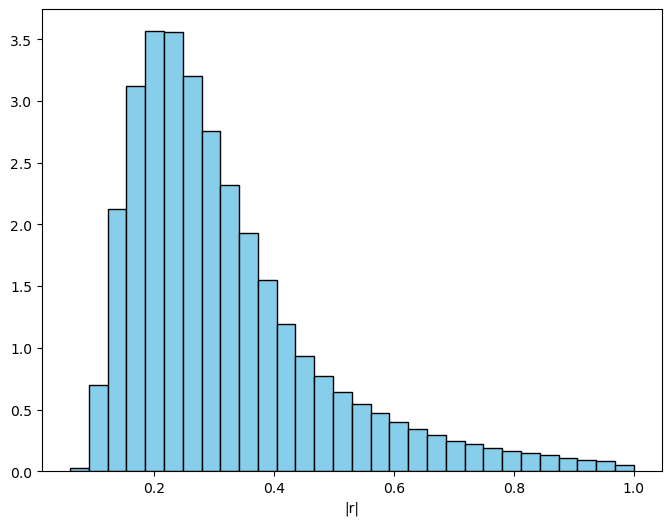

In [ ]:
#histograma de las correlaciones significativas

correlaciones = corr[significant_adj_matrix == 1]


plt.figure(figsize=(8, 6))
plt.hist(np.abs(correlaciones), bins=30, color='skyblue', edgecolor='black', density=True)


#plt.title('Histograma de correlaciones significativas')
plt.xlabel('|r|')

# Mostrar el gráfico
plt.show()

## Conversión de la matriz de correlaciones a la matriz de adyacencia

In [11]:

def hard_adjacency(correlations, threshold):

    adjacency = np.where(np.abs(correlations) >= threshold, 1, 0) #coge el primer numero cuando la condicion es cierta, y el segundo cuando es falsa
    np.fill_diagonal(adjacency, 0)

    return adjacency

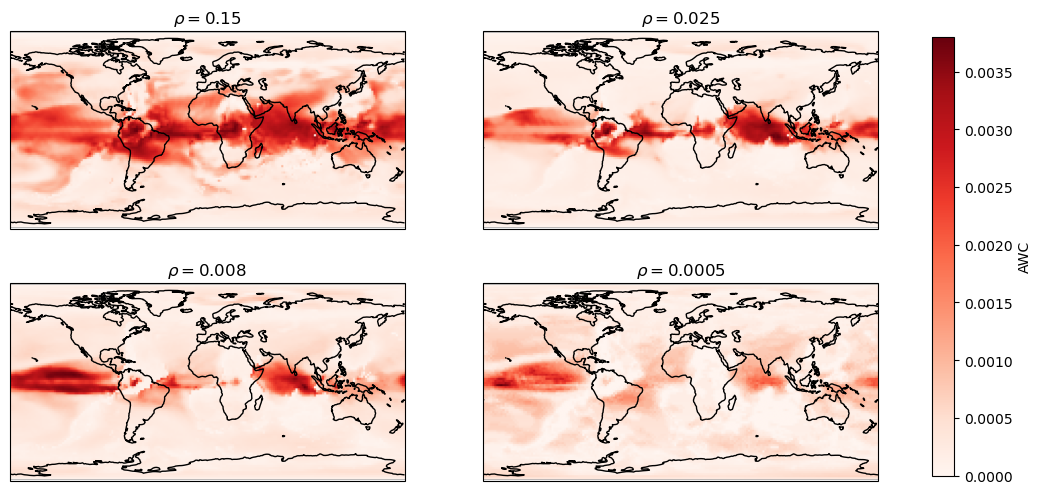

In [ ]:
#codigo para generar 4 cortes
correlaciones =  np.where(significant_adj_matrix == 1, corr, 0)
fig, axs = plt.subplots(2, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
thres_list = [0.2, 0.5, 0.7, 0.95]

lats = np.array([lat for lat, lon in nodos_val]) #para el calculo de AWC
weights = np.cos(np.deg2rad(lats))

lat_min, lat_max = lats.min(), lats.max()


# --- MAPA 1 ---

threshold = thres_list[0]
adj1 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj1)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')


datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs) #esto es para que no salga una linea en medio de la grafica del mapa terrestre
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()] #esto es para que el mapa terrestre salga con el escalado adecuado en cada subplot

axs[0, 0].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa)
axs[0, 0].set_title(rf'$\rho={0.15}$')
axs[0, 0].add_feature(cfeature.COASTLINE, linewidth=1)
axs[0, 0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks([])

del adj1
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa

gc.collect()    # Forzar la liberación de memoria RAM

# --- MAPA 2 ---

threshold = thres_list[1]
adj2 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj2)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs)
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()]

axs[0, 1].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa)
axs[0, 1].set_title(rf'$\rho={0.025}$')
axs[0, 1].add_feature(cfeature.COASTLINE, linewidth=1) 
axs[0, 1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) 
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])

del adj2
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa

gc.collect()    


# --- MAPA 3 ---

threshold = thres_list[2]
adj3 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj3)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs)
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()] 

axs[1, 0].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa)
axs[1, 0].set_title(rf'$\rho={0.008}$')
axs[1, 0].add_feature(cfeature.COASTLINE, linewidth=1) 
axs[1, 0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)
axs[1, 0].set_xticks([])
axs[1, 0].set_yticks([])

del adj3
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa
gc.collect()    

# --- MAPA 4 ---

threshold = thres_list[3]
adj4 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj4)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs) 
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()]

im = axs[1, 1].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa) #usamos im para tomarlo como referencia para la barra de colores
axs[1, 1].set_title(rf'$\rho={0.0005}$')
axs[1, 1].add_feature(cfeature.COASTLINE, linewidth=1) 
axs[1, 1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) 
axs[1, 1].set_xticks([])
axs[1, 1].set_yticks([])

del adj4
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa

gc.collect()

cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.95)
cbar.set_label('AWC')

plt.show()

## Determinación de tau Threshold

Primero analizamos ciertas métricas de la red para distintas threshold

In [ ]:
n_thres = 100

threshold_list = np.linspace(0.1, 1, n_thres)

archivo_csv = "metricas_red.csv"
headers = ["Threshold", "Edge_density", "LCC_Size", "Number_of_components"]
with open(archivo_csv, mode='w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(headers)

    for i in threshold_list: #el for debe estar dentro del with
        adj_matrix = hard_adjacency(correlaciones, i)
        graph = nx.from_numpy_array(adj_matrix)
        density = nx.density(graph)
        components = list(nx.connected_components(graph))
        lcc_size = len(max(components, key=len)) if components else 0
        n_components = len(components)

    
        writer.writerow([i, density, lcc_size, n_components])

        print(i)

        #limpiar RAM entre iteraciones
        f.flush() #esto hace que se guarde el progreso del archivo aunque falle el programa

        del adj_matrix
        del graph
        del components
        gc.collect()


    

0.1
0.1090909090909091
0.1181818181818182
0.1272727272727273
0.13636363636363635
0.14545454545454545
0.15454545454545454
0.16363636363636364
0.17272727272727273
0.18181818181818182
0.19090909090909092
0.2
0.2090909090909091
0.2181818181818182
0.22727272727272727
0.23636363636363636
0.24545454545454545
0.2545454545454545
0.26363636363636367
0.2727272727272727
0.28181818181818186
0.2909090909090909
0.3
0.3090909090909091
0.3181818181818182
0.32727272727272727
0.33636363636363636
0.34545454545454546
0.3545454545454545
0.36363636363636365
0.3727272727272727
0.38181818181818183
0.3909090909090909
0.4
0.40909090909090906
0.4181818181818182
0.42727272727272725
0.4363636363636364
0.44545454545454544
0.4545454545454546
0.4636363636363636
0.47272727272727266
0.4818181818181818
0.49090909090909085
0.5
0.509090909090909
0.5181818181818182
0.5272727272727272
0.5363636363636364
0.5454545454545454
0.5545454545454546
0.5636363636363636
0.5727272727272728
0.5818181818181818
0.5909090909090909
0.6
0.609

In [ ]:
metrics = pd.read_csv("metricas_red.csv")

thresholds = metrics["Threshold"].values
edge_density = metrics["Edge_density"].values
lcc_size = metrics["LCC_Size"].values
n_components = metrics["Number_of_components"].values



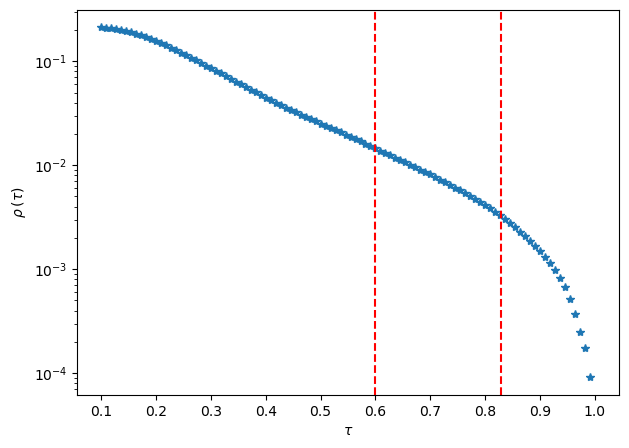

In [ ]:
#grafica a) del articulo de Donges et al
plt.figure(figsize=(7, 5))
plt.plot(thresholds, edge_density, '*')

plt.ylabel(r'$\rho\: (\tau)$')
plt.yscale('log')
#plt.axhline(y=0.02, color='r', linestyle='--', label='Límite y=2') #estas dos lineas de codigo me sirven para saber de forma gráfica donde he de situar las líneas verticales
#plt.axhline(y=0.042, color='r', linestyle='--', label='Límite y=2')

plt.xlabel(r'$\tau$')
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=11)) #mostrar 10 valores en el eje x
plt.axvline(x=0.6, color='r', linestyle='--', label='Límite y=2')
plt.axvline(x=0.83, color='r', linestyle='--', label='Límite y=2')

plt.show()

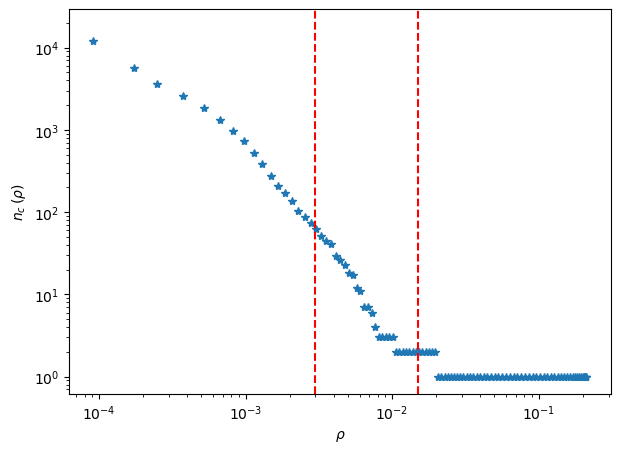

In [11]:
#grafica d) del articulo
plt.figure(figsize=(7, 5))
plt.plot(edge_density, n_components, '*')

plt.xlabel(r'$\rho$')
plt.axvline(x=0.003, color='r', linestyle='--', label='Límite y=2')
plt.axvline(x=0.015, color='r', linestyle='--', label='Límite y=2')
plt.xscale('log')

plt.ylabel(r'$n_c\:(\rho)$')
plt.yscale('log')

plt.show()

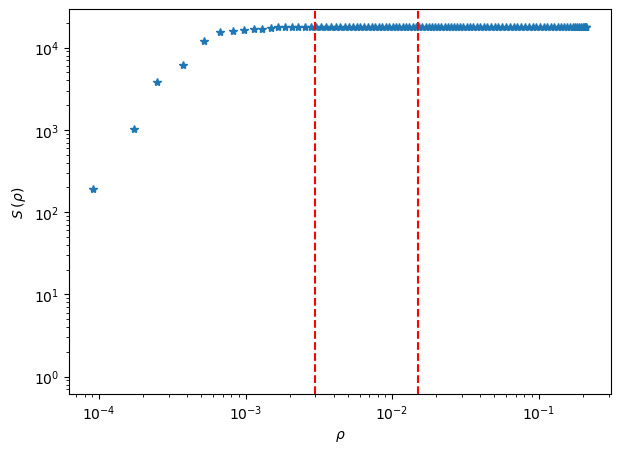

In [12]:
#grafica e) del articulo
plt.figure(figsize=(7, 5))
plt.plot(edge_density, lcc_size, '*')

plt.xlabel(r'$\rho$')
plt.xscale('log')
plt.axvline(x=0.003, color='r', linestyle='--', label='Límite y=2')
plt.axvline(x=0.015, color='r', linestyle='--', label='Límite y=2')

plt.ylabel(r'$S\:(\rho)$')
plt.yscale('log')


plt.show()

# Resultados

In [12]:
threshold = 0.7727272727272727
correlaciones =  np.where(significant_adj_matrix == 1, corr, 0)
adj_matrix = hard_adjacency(correlaciones, threshold)
print(adj_matrix)

[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]


## Grado de cada nodo

In [13]:
#primero me creo el grafo a partir de la matriz de adyacencia
graph = nx.from_numpy_array(adj_matrix)


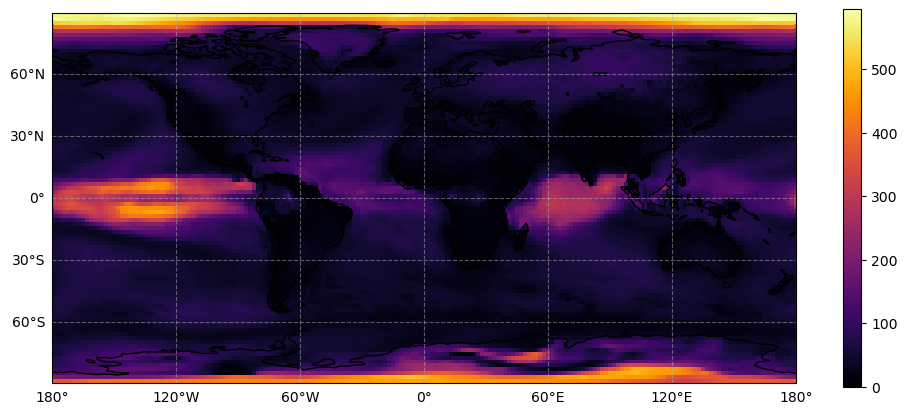

In [ ]:

#ahora obtengo los grados 
degrees = [d for n, d in graph.degree()]

#Creamos un nuevo DataArray con los grados
#Usamos las coordenadas del grid_stacked original para que sepa dónde va cada número
da_grados = xr.DataArray(degrees, coords=coordinates, dims='node')

#Volvemos a la forma 2D (lat, lon)
mapa_grados = da_grados.unstack('node')


plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_grados.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), # Indica que los datos están en lat/lon
    cmap="inferno", 
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Distribución de grado de los nodos")
plt.show()

## Area weighted connectivity

In [ ]:
#el area de cada casilla es proporcional al coseno de la latitud (demostrado en la tablet), por lo que simplemente hemos de aplicar dicha proporcionalidad a
degrees = [d for n, d in graph.degree()]
lats = np.array([lat for lat, lon in nodos_val])
weights = np.cos(np.deg2rad(lats)) 
weighted_degrees = degrees * weights / sum(weights)



da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')

#Volvemos a la forma 2D (lat, lon)
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

np.save("mapa_AWC.npy", mapa_aweighted_grados)

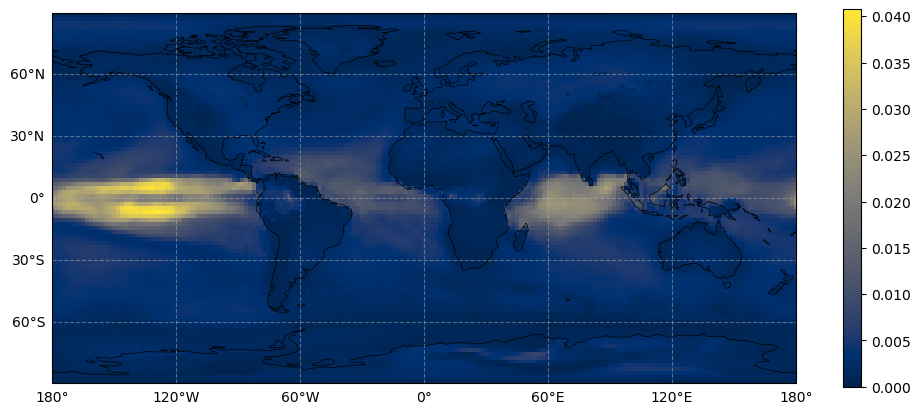

In [ ]:
lats = sorted(list(set(lat for lat, lon in nodos_val)), reverse=True) # reverse=True si van de Norte a Sur
longs = sorted(list(set(lon for lat, lon in nodos_val)))

mapa_aweighted_grados = xr.DataArray(
    np.load("mapa_AWC.npy"), 
    coords=[('lat', lats), ('lon', longs)]
)

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())




mapa_aweighted_grados.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap="cividis", 
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=0.5) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Area weighted connectivity")
plt.show()

## Clustering

In [ ]:
clustering_dict = nx.clustering(graph)

clustering_vector = [clustering_dict[i] for i in range(len(graph.nodes))]


da_clustering = xr.DataArray(
    clustering_vector, 
    coords={'node': nodos}, 
    dims='node'
)

# Volver a 2D
mapa_clustering = da_clustering.unstack('node')
np.save("mapa_clustering.npy", mapa_clustering)

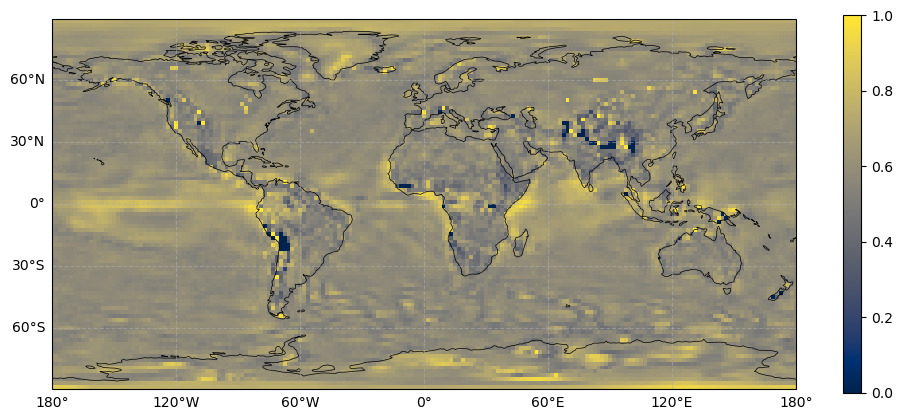

In [ ]:
lats = sorted(list(set(lat for lat, lon in nodos_val)), reverse=True) # reverse=True si van de Norte a Sur
longs = sorted(list(set(lon for lat, lon in nodos_val)))

mapa_clustering = xr.DataArray(
    np.load("mapa_clustering.npy"), 
    coords=[('lat', lats), ('lon', longs)]
)


plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_clustering.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap="cividis",
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=0.5) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Clustering")
plt.show()

## Closeness centrality

In [ ]:
closeness_dict = nx.closeness_centrality(graph)
closeness_vector = [closeness_dict[i] for i in range(len(graph.nodes))]

da_closeness = xr.DataArray(
    closeness_vector, 
    coords={'node': nodos}, 
    dims='node'
)


mapa_closeness = da_closeness.unstack('node')
np.save("mapa_closeness.npy", mapa_closeness)

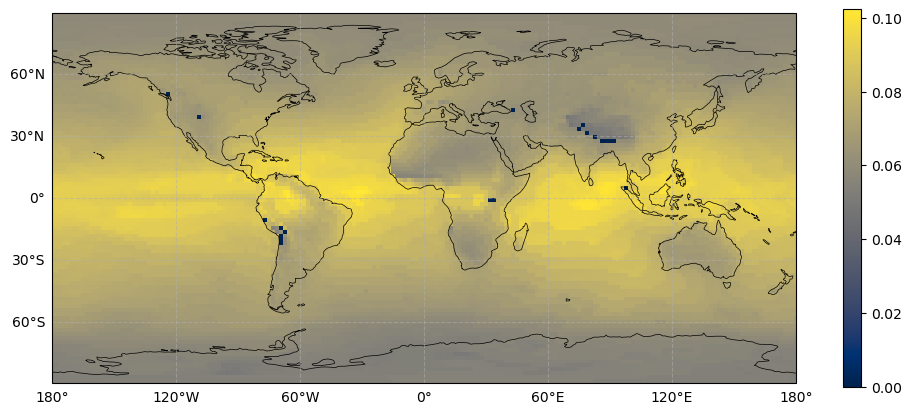

In [ ]:
lats = sorted(list(set(lat for lat, lon in nodos_val)), reverse=True) # reverse=True si van de Norte a Sur
longs = sorted(list(set(lon for lat, lon in nodos_val)))

mapa_closeness = xr.DataArray(
    np.load("mapa_closeness.npy"), 
    coords=[('lat', lats), ('lon', longs)]
)

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_closeness.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap="cividis",
    cbar_kwargs={'shrink': 0.7} 
)


ax.add_feature(cfeature.COASTLINE, linewidth=0.5) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Closeness centrality")
plt.show()

## Betweenness

In [24]:
bet_dict = nx.betweenness_centrality(graph, k=None, normalized=False)
bet_vector = [bet_dict.get(i, 0) for i in range(len(graph.nodes))]
log_bet_vector = np.log1p(bet_vector)
log_da_betweenness = xr.DataArray(log_bet_vector, coords={'node': nodos}, dims='node')
log_mapa_betweenness = log_da_betweenness.unstack('node')
np.save("mapa_betweenness.npy", log_mapa_betweenness)

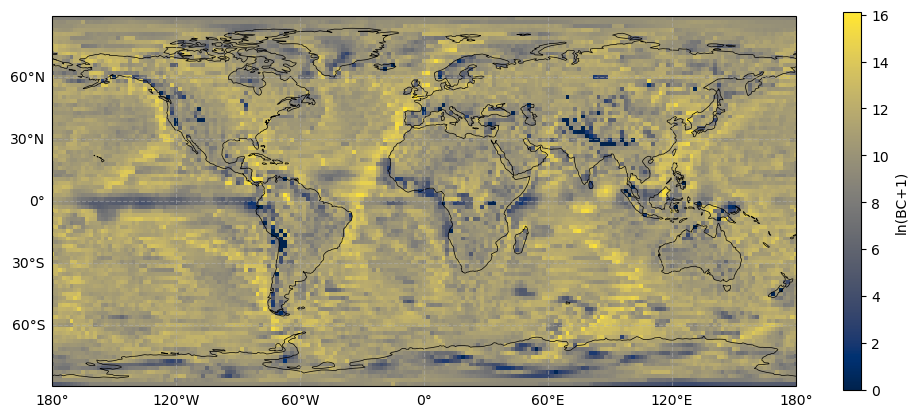

In [ ]:
lats = sorted(list(set(lat for lat, lon in nodos_val)), reverse=True) # reverse=True si van de Norte a Sur
longs = sorted(list(set(lon for lat, lon in nodos_val)))

log_mapa_betweenness = xr.DataArray(
    np.load("mapa_betweenness.npy"), 
    coords=[('lat', lats), ('lon', longs)]
)

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


log_mapa_betweenness.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap="cividis",
    cbar_kwargs={
        'shrink': 0.7,
        'label': 'ln(BC+1)' 
    }
)


ax.add_feature(cfeature.COASTLINE, linewidth=0.5) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Betweenness centrality")
plt.show()

# Detrending

In [7]:
anomalies_pasado = anomalies.isel(time=slice(0, 240)) #primeros 20 años
anomalies_actual = anomalies.isel(time=slice(-240, None)) #últimos 20 años

## Pasado

In [8]:
corr, nodos_val, coordinates, nodos = fast_corr_matrix(anomalies_pasado)

p_values = np.zeros(corr.shape)
n_exp = 100

for j in range(n_exp):

    ran_anomalies = gen_random_grid(anomalies_pasado)
    correlaciones_ranf = np.corrcoef(ran_anomalies, rowvar=False)

    p_values += (np.abs(corr) < np.abs(correlaciones_ranf))

p_values = p_values/(n_exp+1)

#benjamini-hochberg correction

significance = 0.01

flat_p_values = p_values.reshape(-1)
ordered_p_values = sorted(flat_p_values)
testing = np.zeros(len(ordered_p_values))

N2 = corr[0].size**2

for i in range(p_values.size):
    testing[i]=i*significance/N2
    if testing[i] < ordered_p_values[i]:
        ordered_p_values[i] = 0

significant_adj_matrix = np.where(p_values > np.max(ordered_p_values), 0, 1)
np.fill_diagonal(significant_adj_matrix, 0)

correlaciones = corr[significant_adj_matrix == 1]


Calculando matriz de correlacion


In [9]:
threshold = 0.8
correlaciones =  np.where(significant_adj_matrix == 1, corr, 0)
adj_matrix = hard_adjacency(correlaciones, threshold)

graph = nx.from_numpy_array(adj_matrix)

AWC

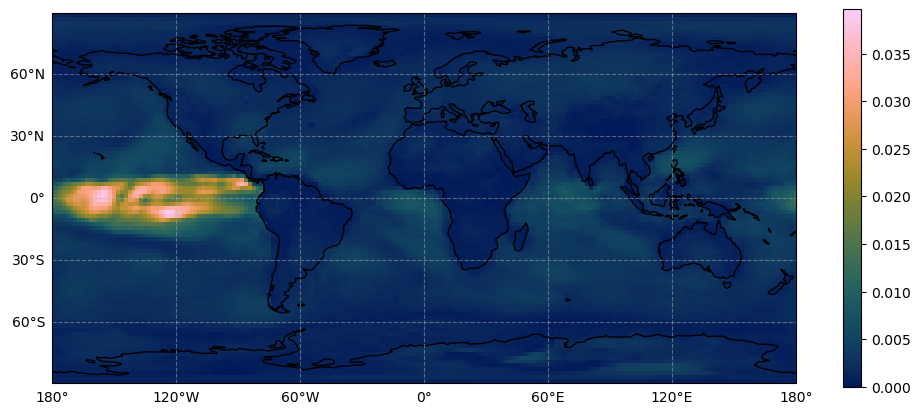

In [ ]:
degrees = [d for n, d in graph.degree()]
lats = np.array([lat for lat, lon in nodos_val])
weights = np.cos(np.deg2rad(lats)) 
weighted_degrees = degrees * weights / sum(weights)


da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')

#Volvemos a la forma 2D (lat, lon)
mapa_aweighted_grados = da_aweighted_grados.unstack('node')


plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_aweighted_grados.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow, 
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Area weighted connectivity")
plt.show()


In [11]:
np.save("mapa_AWC_pasado.npy", mapa_aweighted_grados)

Clustering

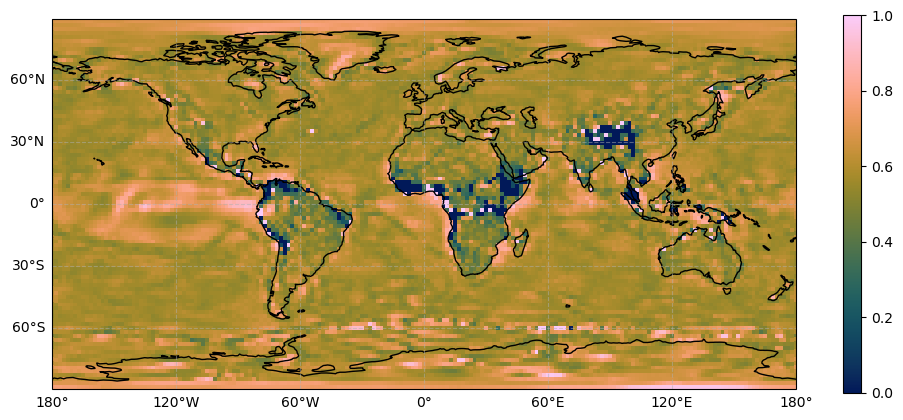

In [ ]:
clustering_dict = nx.clustering(graph)

clustering_vector = [clustering_dict[i] for i in range(len(graph.nodes))]

da_clustering = xr.DataArray(
    clustering_vector, 
    coords={'node': nodos}, 
    dims='node'
)

# Volver a 2D 
mapa_clustering = da_clustering.unstack('node')


plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_clustering.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow,
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Clustering")
plt.show()

Closeness

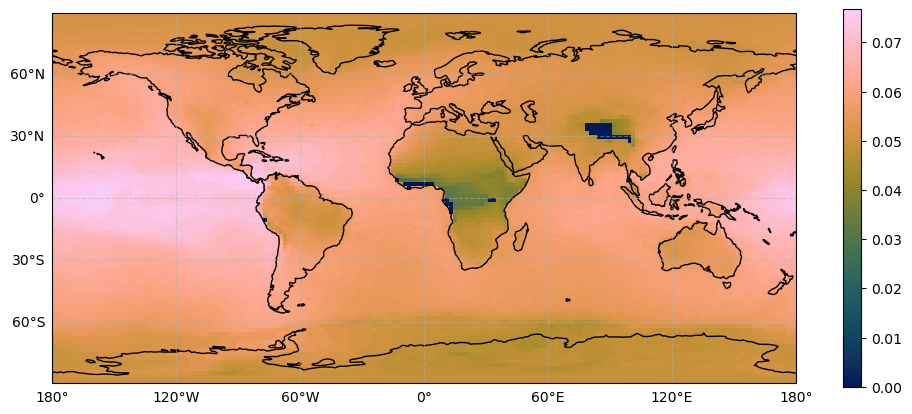

In [ ]:
closeness_dict = nx.closeness_centrality(graph)
closeness_vector = [closeness_dict[i] for i in range(len(graph.nodes))]

da_closeness = xr.DataArray(
    closeness_vector, 
    coords={'node': nodos}, 
    dims='node'
)


mapa_closeness = da_closeness.unstack('node')

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_closeness.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow,
    cbar_kwargs={'shrink': 0.7} 
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Closeness centrality")
plt.show()

Betweeness

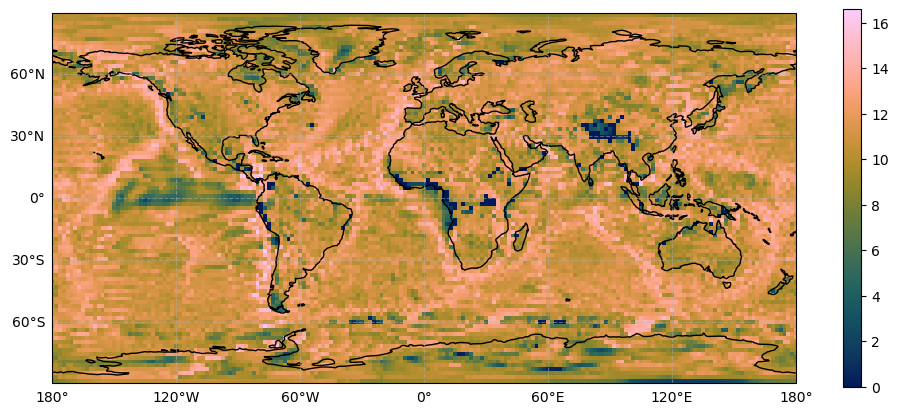

In [ ]:
bet_dict = nx.betweenness_centrality(graph, k=None, normalized=False)
bet_vector = [bet_dict.get(i, 0) for i in range(len(graph.nodes))]
log_bet_vector = np.log1p(bet_vector)
log_da_betweenness = xr.DataArray(log_bet_vector, coords={'node': nodos}, dims='node')
log_mapa_betweenness = log_da_betweenness.unstack('node')

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


log_mapa_betweenness.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow,
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Betweenness centrality")
plt.show()

## Presente

In [10]:
corr, nodos_val, coordinates, nodos = fast_corr_matrix(anomalies_actual)

p_values = np.zeros(corr.shape)
n_exp = 100

for j in range(n_exp):

    ran_anomalies = gen_random_grid(anomalies_actual)
    correlaciones_ranf = np.corrcoef(ran_anomalies, rowvar=False)

    p_values += (np.abs(corr) < np.abs(correlaciones_ranf))

p_values = p_values/(n_exp+1)

#benjamini-hochberg correction

significance = 0.01

flat_p_values = p_values.reshape(-1)
ordered_p_values = sorted(flat_p_values)
testing = np.zeros(len(ordered_p_values))

N2 = corr[0].size**2

for i in range(p_values.size):
    testing[i]=i*significance/N2
    if testing[i] < ordered_p_values[i]:
        ordered_p_values[i] = 0

significant_adj_matrix = np.where(p_values > np.max(ordered_p_values), 0, 1)
np.fill_diagonal(significant_adj_matrix, 0)

correlaciones = corr[significant_adj_matrix == 1]


Calculando matriz de correlacion


In [11]:
threshold = 0.8
correlaciones =  np.where(significant_adj_matrix == 1, corr, 0)
adj_matrix = hard_adjacency(correlaciones, threshold)

graph = nx.from_numpy_array(adj_matrix)

AWC

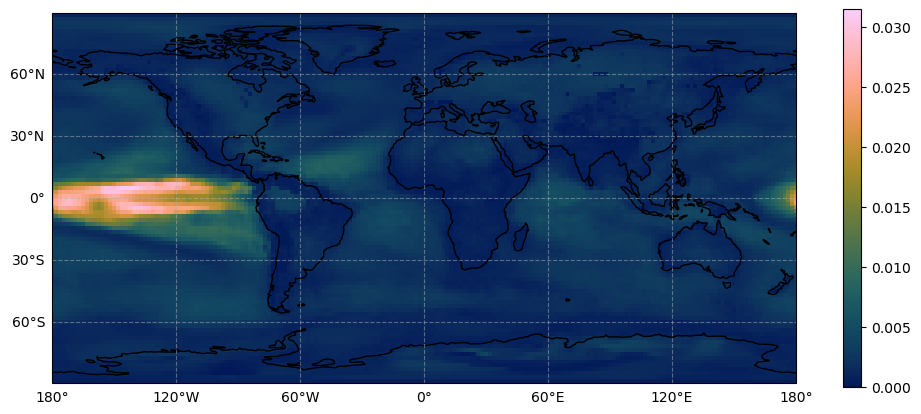

In [ ]:
degrees = [d for n, d in graph.degree()]
lats = np.array([lat for lat, lon in nodos_val])
weights = np.cos(np.deg2rad(lats)) 
weighted_degrees = degrees * weights / sum(weights)

da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')

#Volvemos a la forma 2D (lat, lon)
mapa_aweighted_grados = da_aweighted_grados.unstack('node')


plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_aweighted_grados.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow, 
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadricula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Area weighted connectivity")
plt.show()


In [16]:
np.save("mapa_AWC_presente.npy", mapa_aweighted_grados)

Clustering

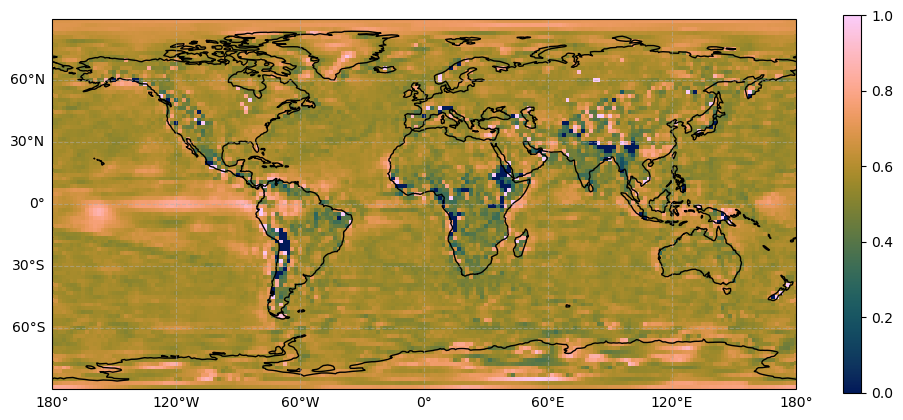

In [ ]:
clustering_dict = nx.clustering(graph)

clustering_vector = [clustering_dict[i] for i in range(len(graph.nodes))]

da_clustering = xr.DataArray(
    clustering_vector, 
    coords={'node': nodos}, 
    dims='node'
)

# Volver a 2D
mapa_clustering = da_clustering.unstack('node')


plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_clustering.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow,
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Clustering")
plt.show()

Closeness

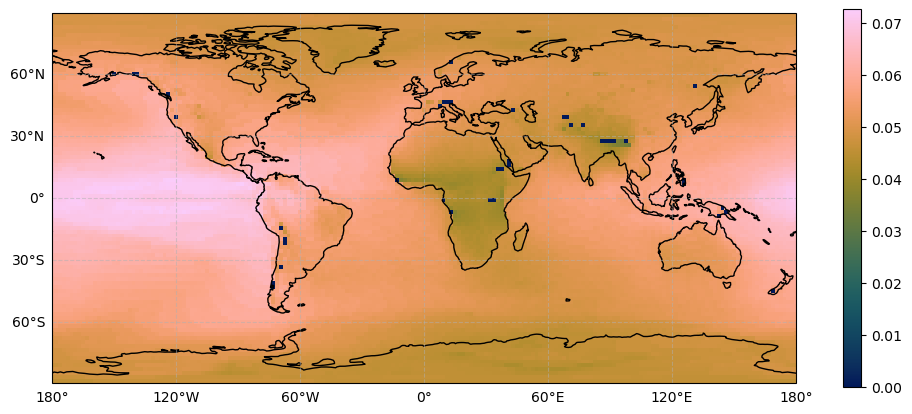

In [ ]:
closeness_dict = nx.closeness_centrality(graph)
closeness_vector = [closeness_dict[i] for i in range(len(graph.nodes))]

da_closeness = xr.DataArray(
    closeness_vector, 
    coords={'node': nodos}, 
    dims='node'
)


mapa_closeness = da_closeness.unstack('node')

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


mapa_closeness.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow,
    cbar_kwargs={'shrink': 0.7} 
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadricula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Closeness centrality")
plt.show()

Betweenness

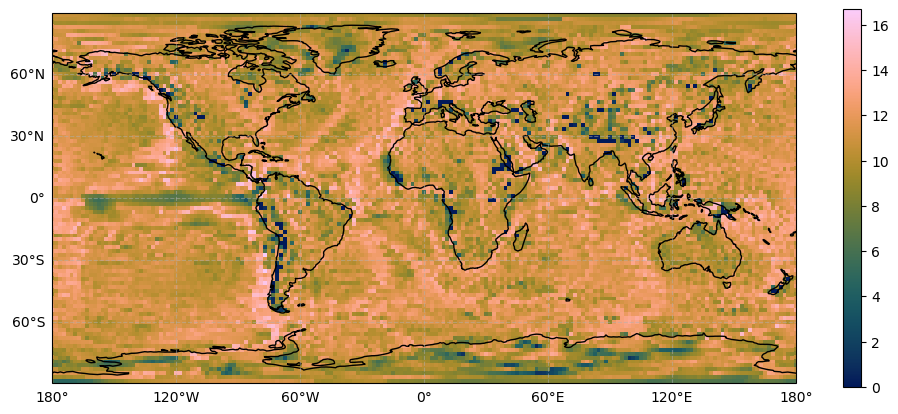

In [ ]:
bet_dict = nx.betweenness_centrality(graph, k=None, normalized=False)
bet_vector = [bet_dict.get(i, 0) for i in range(len(graph.nodes))]
log_bet_vector = np.log1p(bet_vector)
log_da_betweenness = xr.DataArray(log_bet_vector, coords={'node': nodos}, dims='node')
log_mapa_betweenness = log_da_betweenness.unstack('node')

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


log_mapa_betweenness.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow,
    cbar_kwargs={'shrink': 0.7}
)


ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadrícula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Betweenness centrality")
plt.show()

## Diferencias presente/pasado

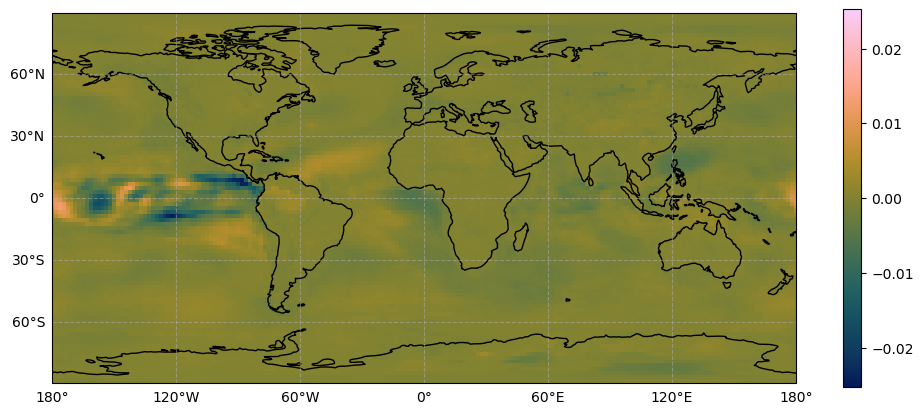

In [ ]:
#evolucion del AWC

mapa_presente = np.load("mapa_AWC_presente.npy")
mapa_pasado = np.load("mapa_AWC_pasado.npy")

diferencia = mapa_presente - mapa_pasado

lats = sorted(list(set(lat for lat, lon in nodos_val)), reverse=True) # reverse=True si van de Norte a Sur
longs = sorted(list(set(lon for lat, lon in nodos_val)))

diferencia_xr = xr.DataArray(
    diferencia, 
    coords=[('lat', lats), ('lon', longs)]
)

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())


diferencia_xr.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cm.batlow, 
    cbar_kwargs={'shrink': 0.7}
)

ax.add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5) # Fronteras políticas
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra

#cuadricula
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#plt.title("Area weighted connectivity")
plt.show()